<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/College_Student_Placement_Dataset_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('college_student_placement_dataset 2.csv')
df.head(11)

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No
5,CLG0015,96,5.26,5.32,7,No,5,8,0,No
6,CLG0071,123,6.68,6.58,5,No,7,8,2,Yes
7,CLG0096,111,8.77,8.76,7,No,3,1,2,Yes
8,CLG0097,92,6.47,6.33,9,No,7,8,5,No
9,CLG0057,108,8.82,8.60,4,No,5,9,1,No


In [4]:
df.tail(11)

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
9989,CLG0001,88,6.56,6.49,8,Yes,9,10,2,No
9990,CLG0046,121,5.58,5.27,9,No,7,3,2,No
9991,CLG0005,102,7.28,6.86,10,Yes,9,3,1,No
9992,CLG0062,109,9.92,10.09,2,Yes,5,10,3,Yes
9993,CLG0056,77,7.57,7.39,1,Yes,2,6,3,No
9994,CLG0064,117,8.71,8.44,6,No,9,4,4,Yes
9995,CLG0021,119,8.41,8.29,4,No,1,8,0,Yes
9996,CLG0098,70,9.25,9.34,7,No,0,7,2,No
9997,CLG0066,89,6.08,6.25,3,Yes,3,9,5,No
9998,CLG0045,107,8.77,8.92,3,No,7,5,1,No


In [5]:
df.shape

(10000, 10)

In [6]:
df.columns

Index(['College_ID', 'IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance',
       'Internship_Experience', 'Extra_Curricular_Score',
       'Communication_Skills', 'Projects_Completed', 'Placement'],
      dtype='object')

In [8]:
df.dtypes

,0
College_ID,object
IQ,int64
Prev_Sem_Result,float64
CGPA,float64
Academic_Performance,int64
Internship_Experience,object
Extra_Curricular_Score,int64
Communication_Skills,int64
Projects_Completed,int64
Placement,object


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  object 
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  object 
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB


In [10]:
df.describe(include = 'all')

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
count,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000,10000.000000,10000.000000,10000.000000,10000
unique,100,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,2
top,CLG0062,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,No
freq,133,NaN,NaN,NaN,NaN,6036,NaN,NaN,NaN,8341
mean,NaN,99.471800,7.535673,7.532379,5.546400,NaN,4.970900,5.561800,2.513400,NaN
std,NaN,15.053101,1.447519,1.470141,2.873477,NaN,3.160103,2.900866,1.715959,NaN
min,NaN,41.000000,5.000000,4.540000,1.000000,NaN,0.000000,1.000000,0.000000,NaN
25%,NaN,89.000000,6.290000,6.290000,3.000000,NaN,2.000000,3.000000,1.000000,NaN
50%,NaN,99.000000,7.560000,7.550000,6.000000,NaN,5.000000,6.000000,3.000000,NaN
75%,NaN,110.000000,8.790000,8.770000,8.000000,NaN,8.000000,8.000000,4.000000,NaN


In [11]:
df.isnull().sum()

,0
College_ID,0
IQ,0
Prev_Sem_Result,0
CGPA,0
Academic_Performance,0
Internship_Experience,0
Extra_Curricular_Score,0
Communication_Skills,0
Projects_Completed,0
Placement,0


In [12]:
df.duplicated().sum()

np.int64(0)

# Handling Outliers

In [13]:
Q1 = df['IQ'].quantile(0.25)
Q3 = df['IQ'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_outliers = df[(df['IQ'] >= lower_bound) & (df['IQ'] <= upper_bound)].copy()

print('Before removing Outliers:', len(df))
print('After removing Outliers:', len(df_outliers))

Before removing Outliers: 10000
After removing Outliers: 9939


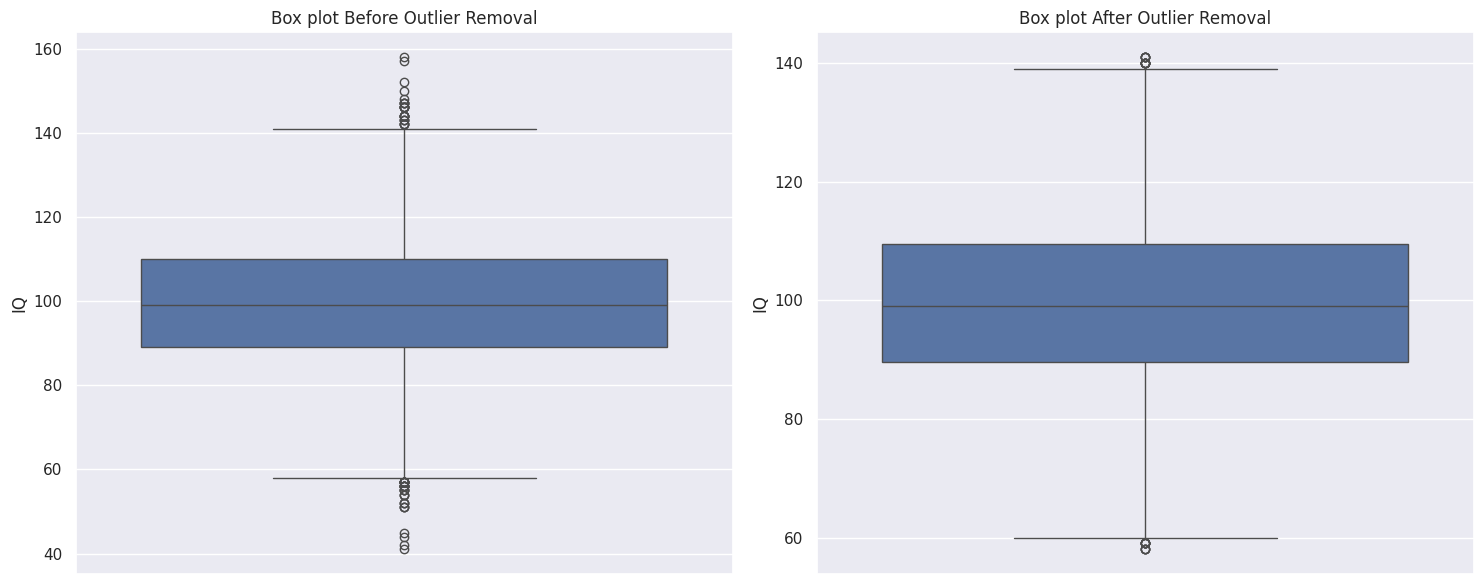

In [14]:
# Creating a figure with two subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(data=df, y='IQ', ax=axes[0])
axes[0].set_title('Box plot Before Outlier Removal')
axes[0].set_ylabel('IQ')

sns.boxplot(data=df_outliers, y='IQ', ax=axes[1])
axes[1].set_title('Box plot After Outlier Removal')
axes[1].set_ylabel('IQ')

plt.tight_layout()
plt.show()

# Univariate Analysis

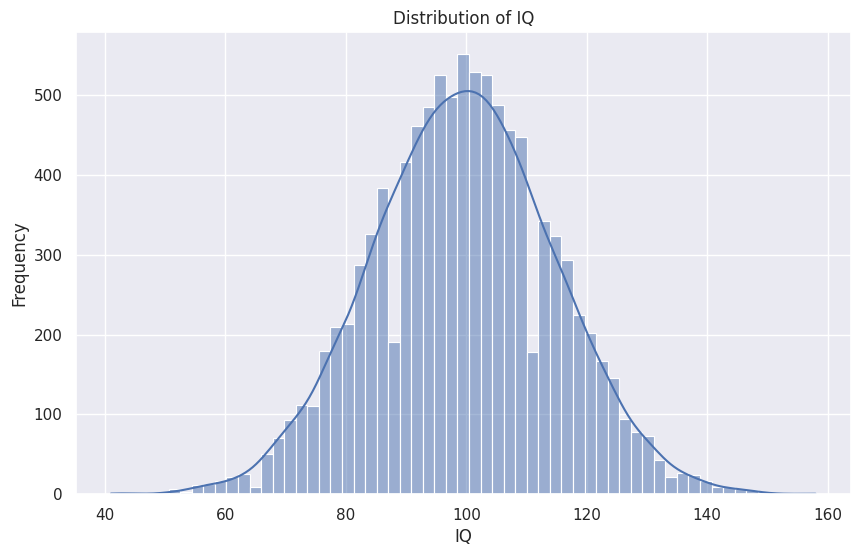

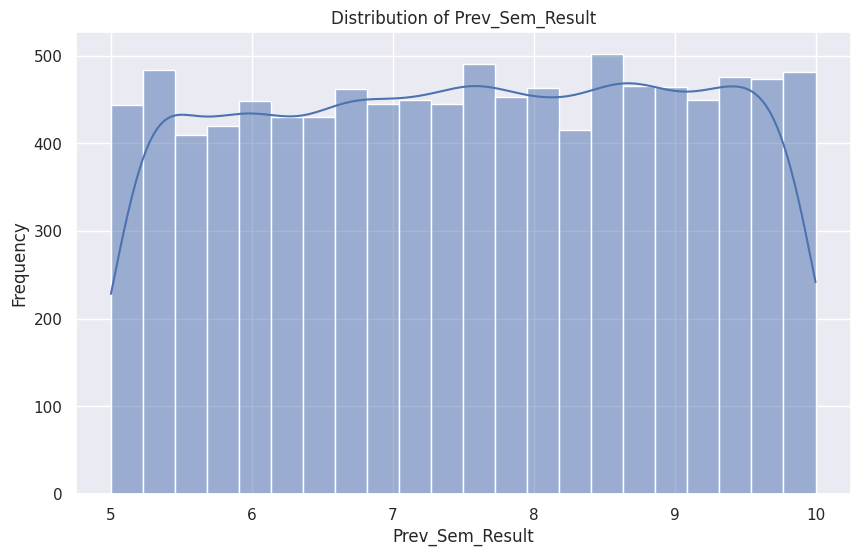

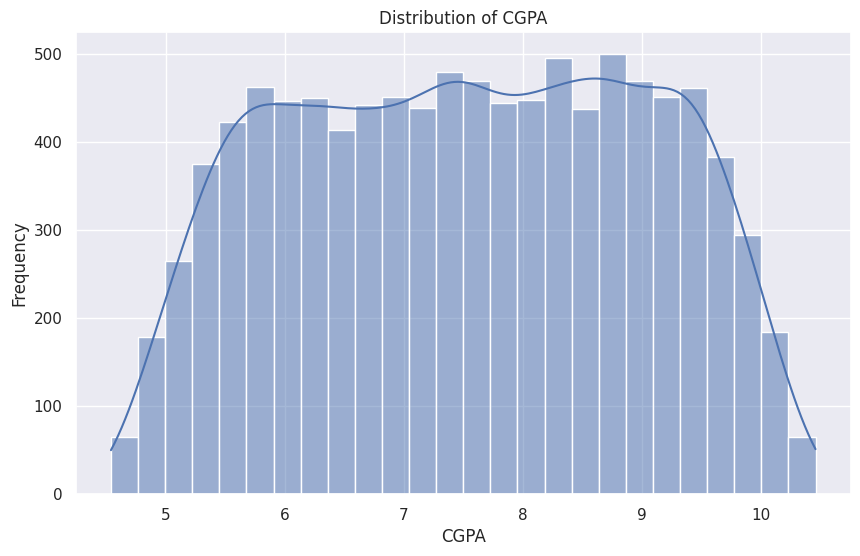

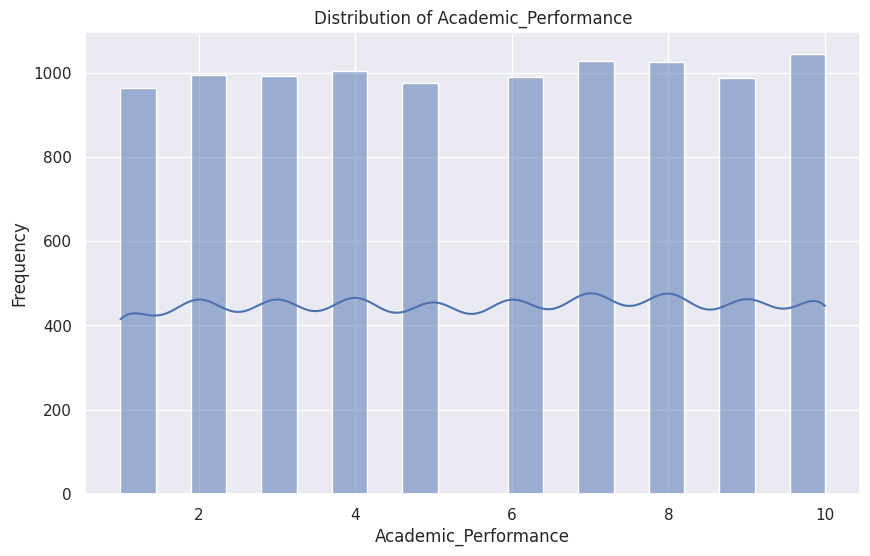

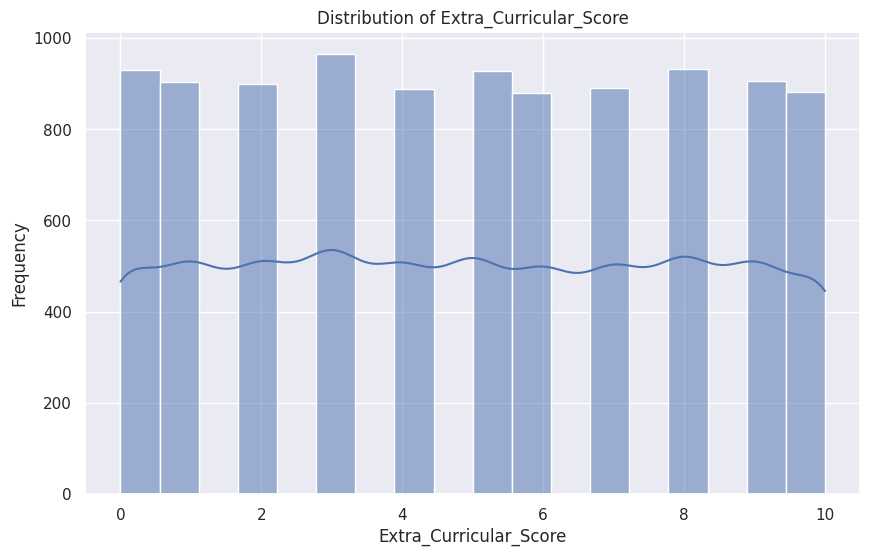

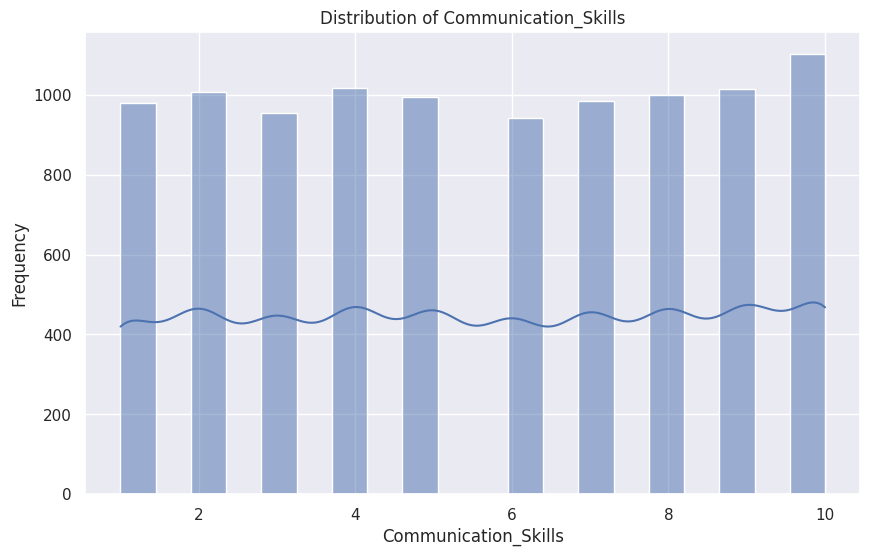

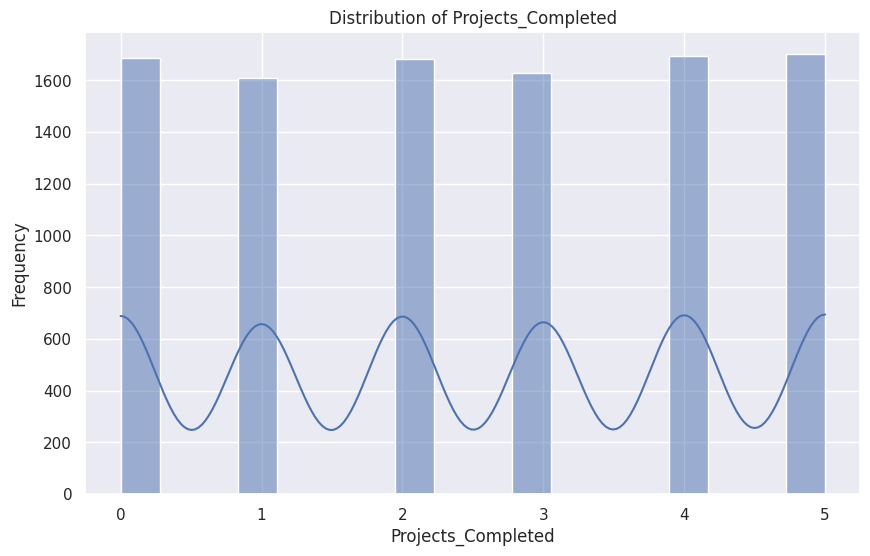

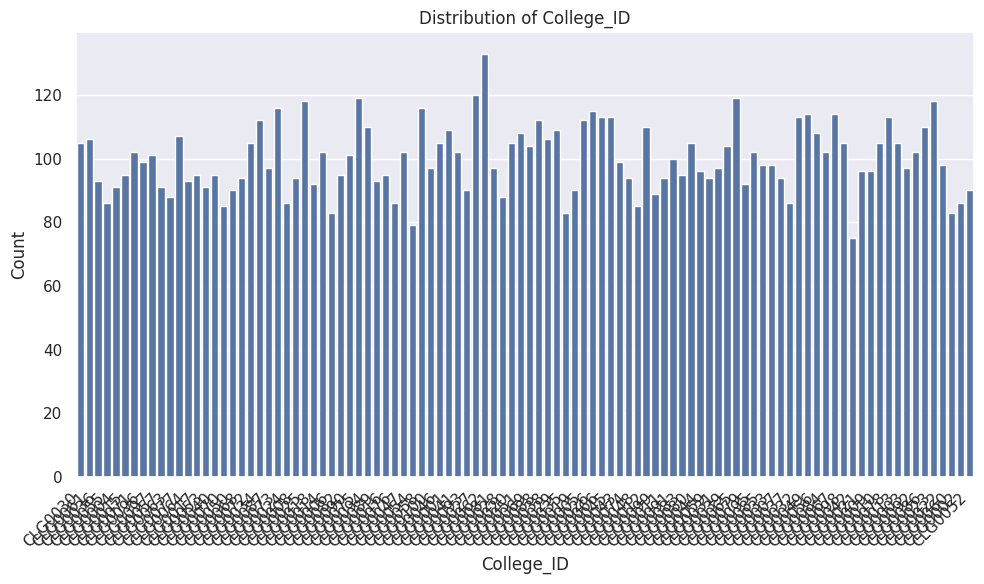

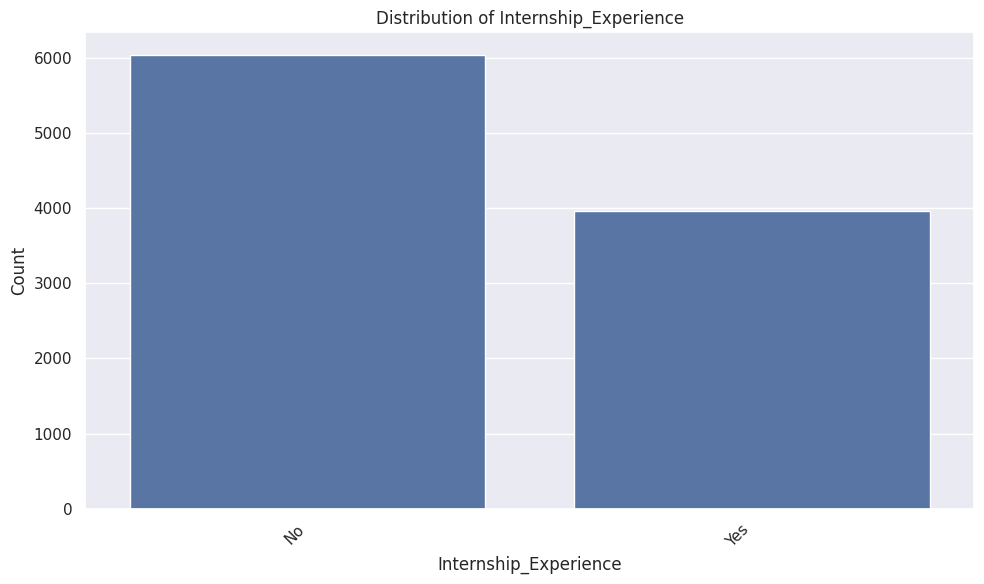

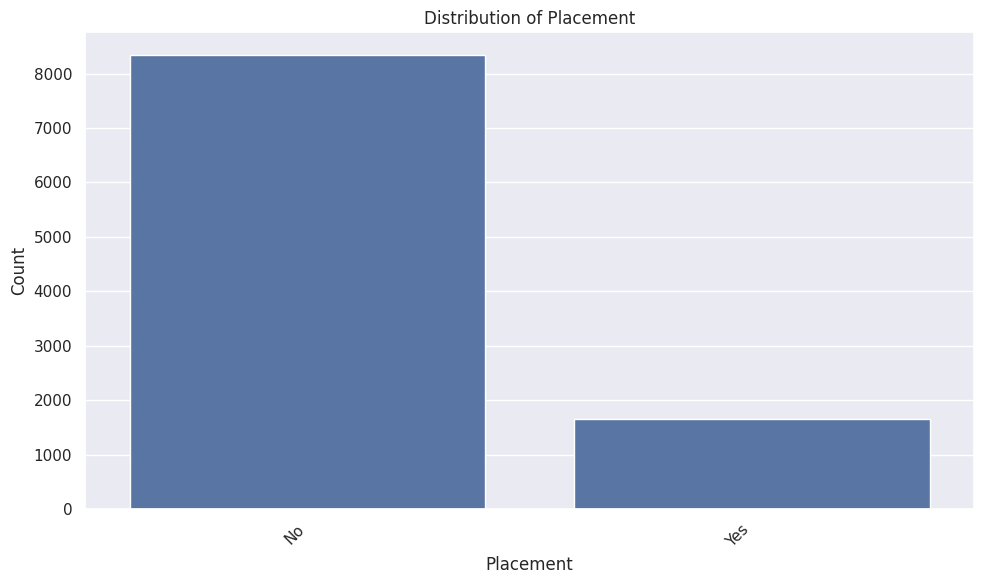

Value counts for College_ID:
College_ID
CLG0062    133
CLG0027    120
CLG0075    119
CLG0065    119
CLG0023    118
          ... 
CLG0006     83
CLG0060     83
CLG0035     83
CLG0054     79
CLG0042     75
Name: count, Length: 100, dtype: int64

Value counts for Internship_Experience:
Internship_Experience
No     6036
Yes    3964
Name: count, dtype: int64

Value counts for Placement:
Placement
No     8341
Yes    1659
Name: count, dtype: int64



In [15]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

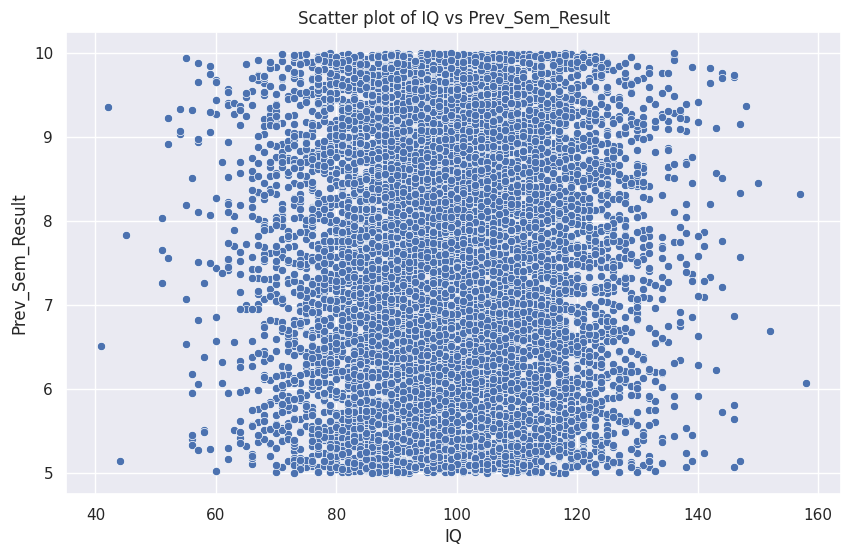

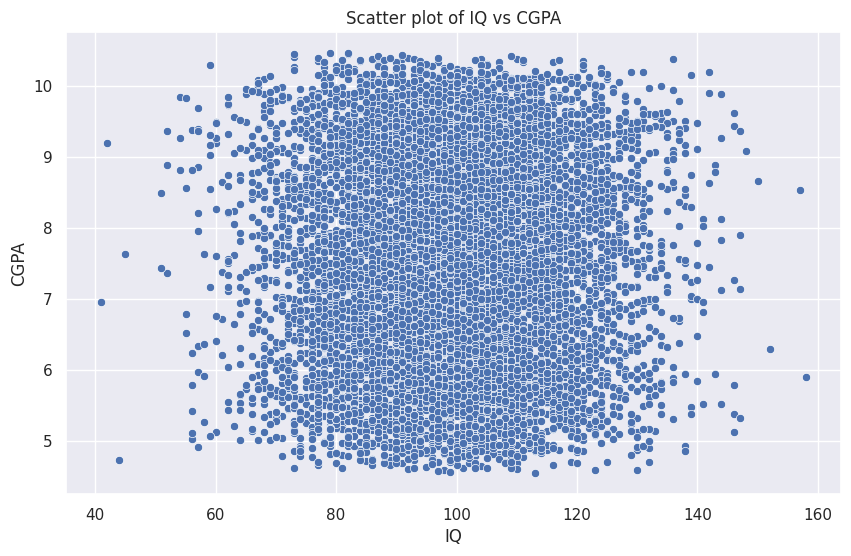

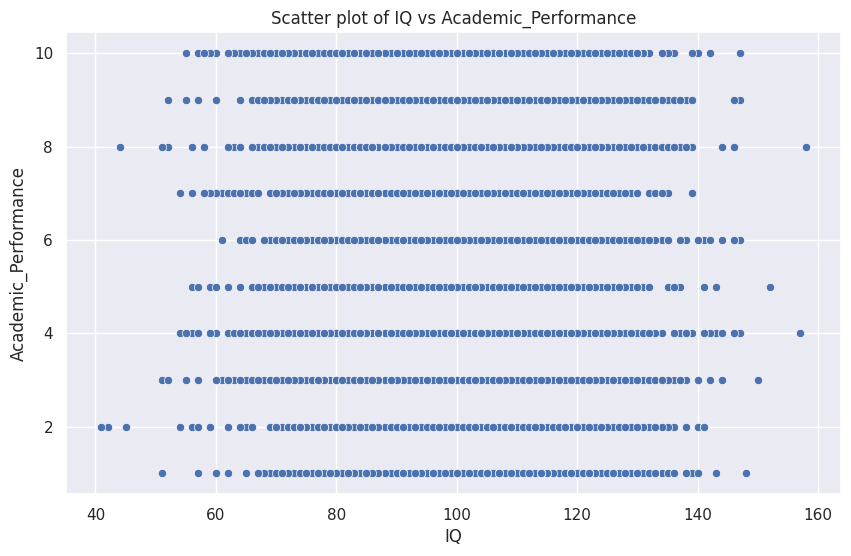

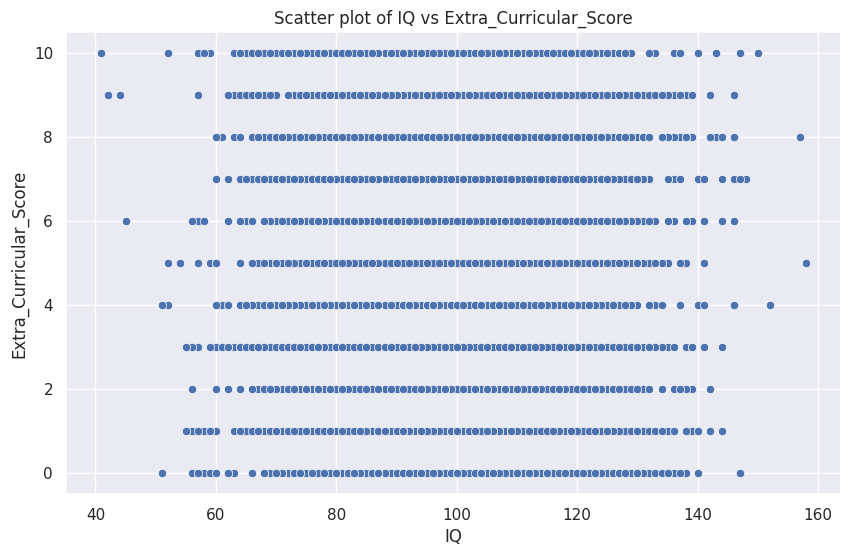

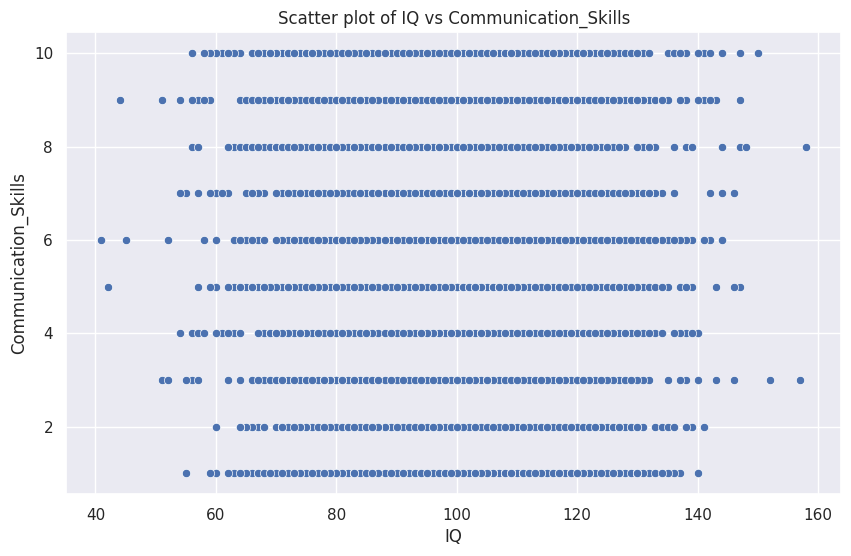

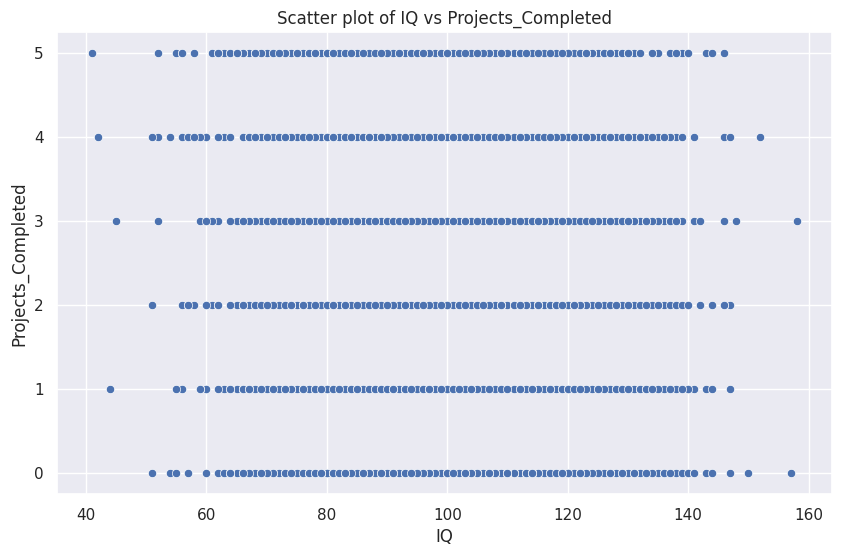

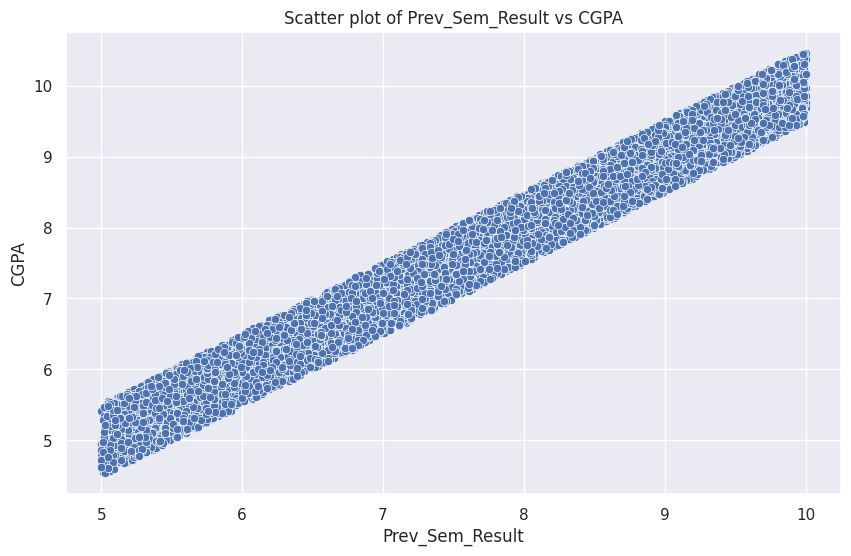

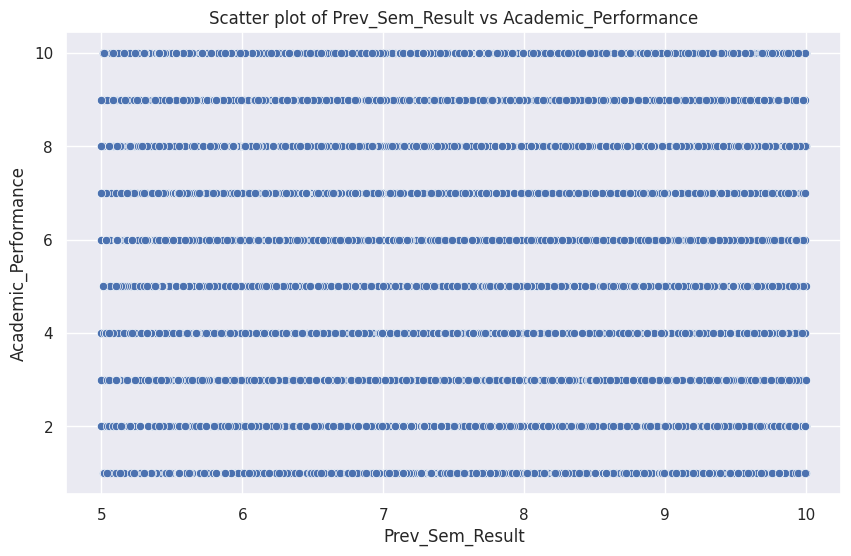

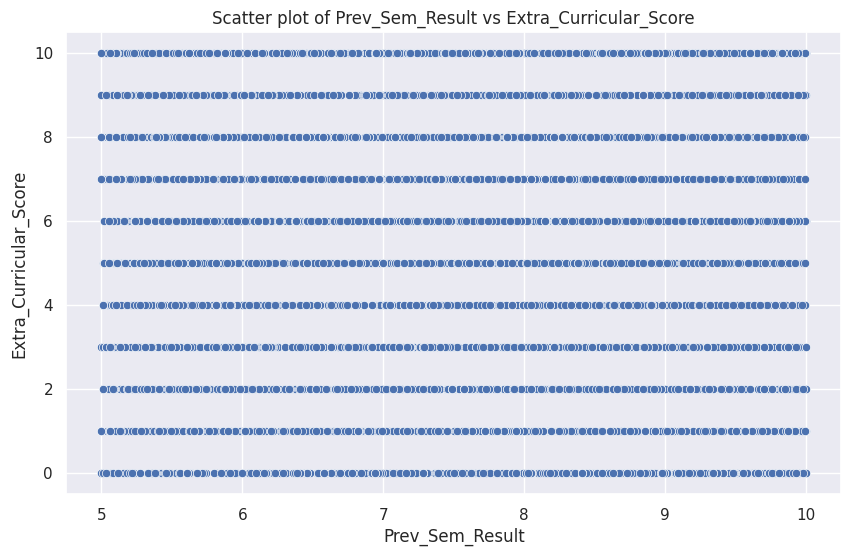

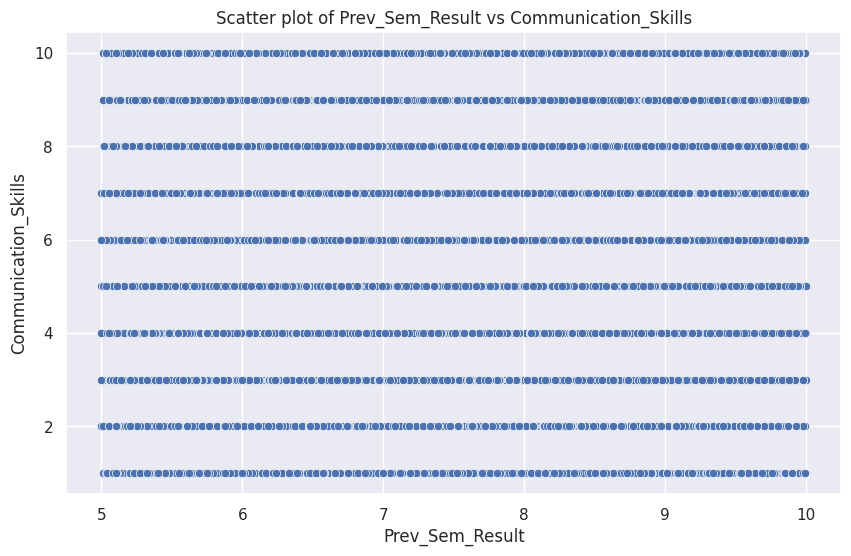

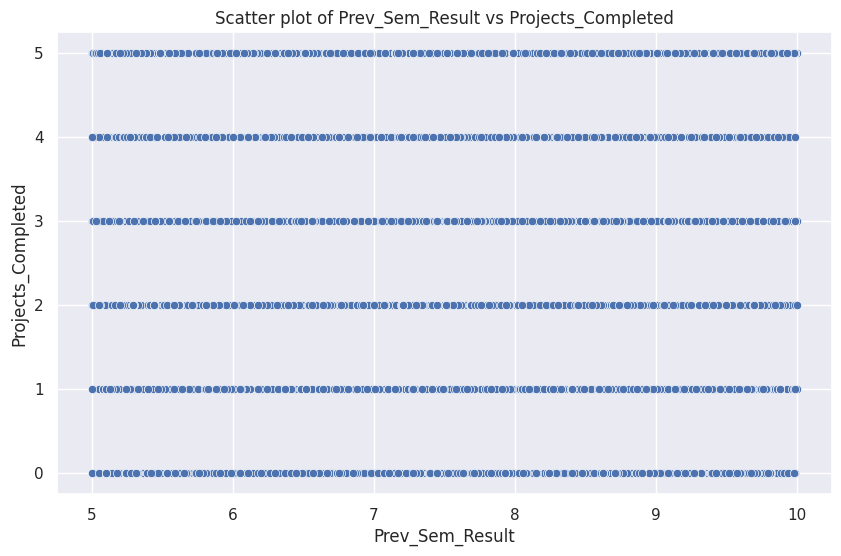

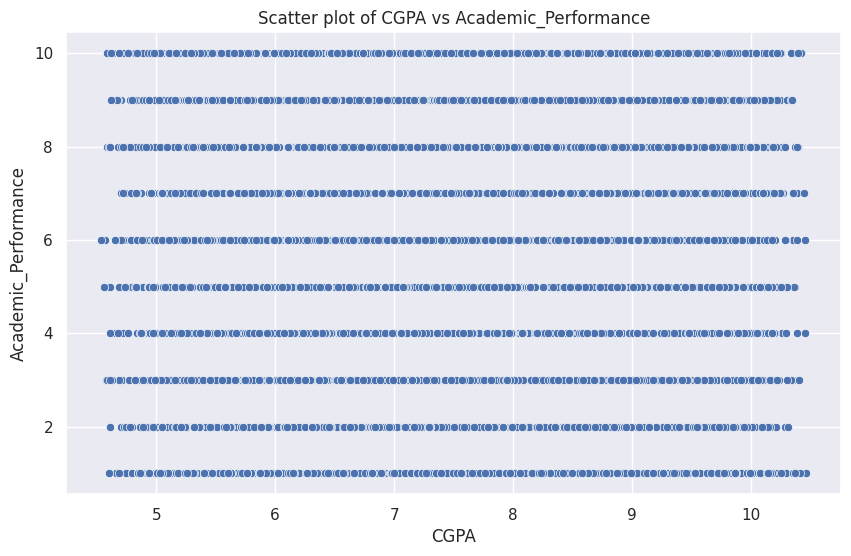

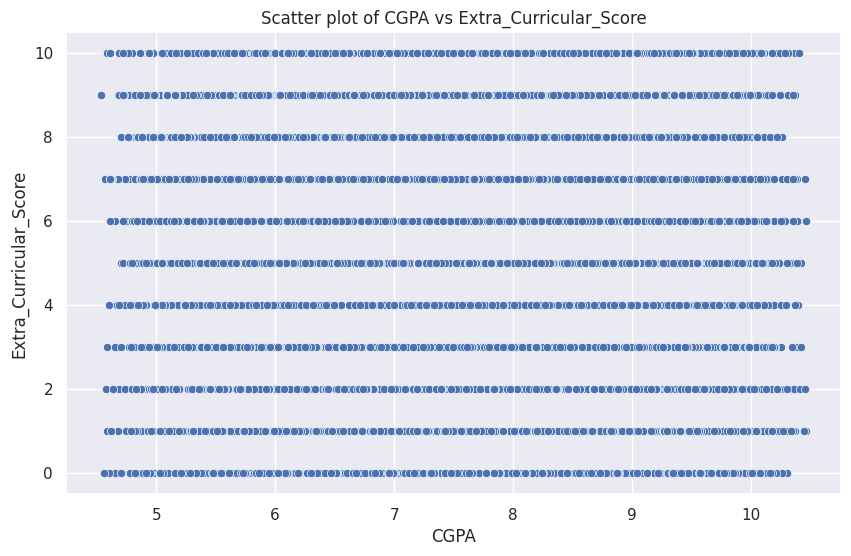

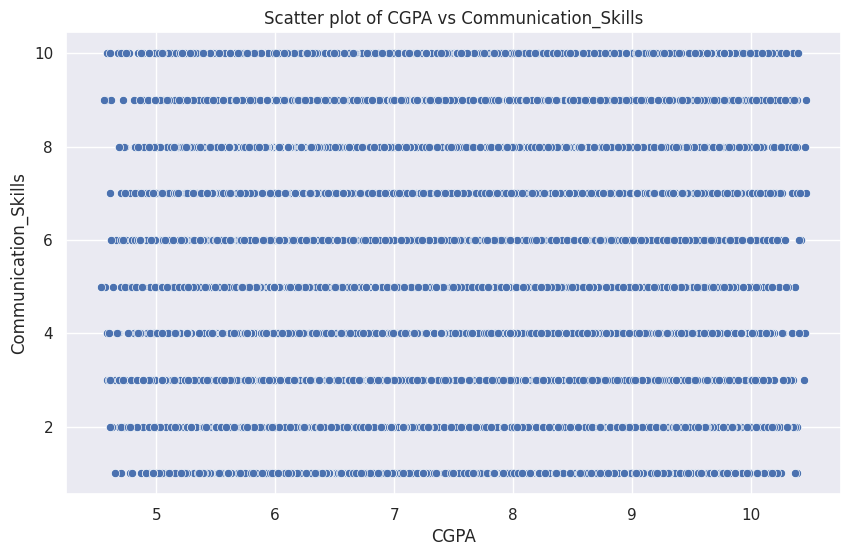

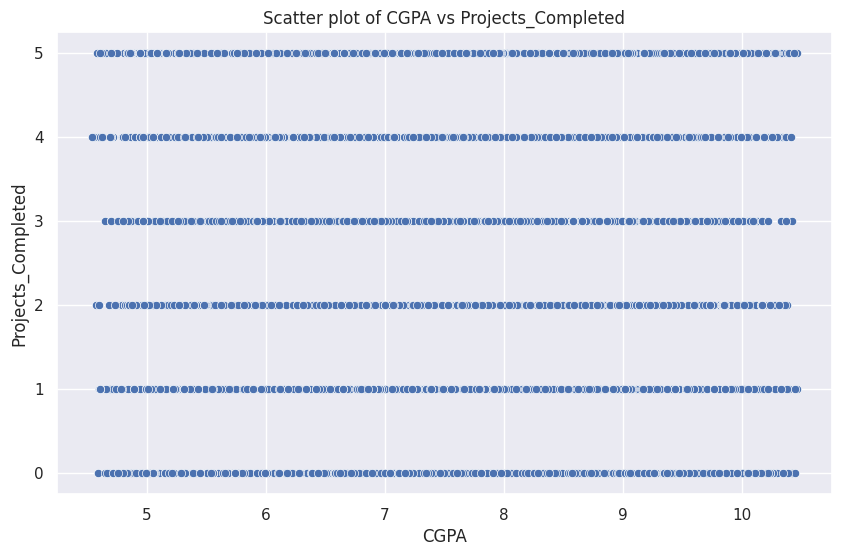

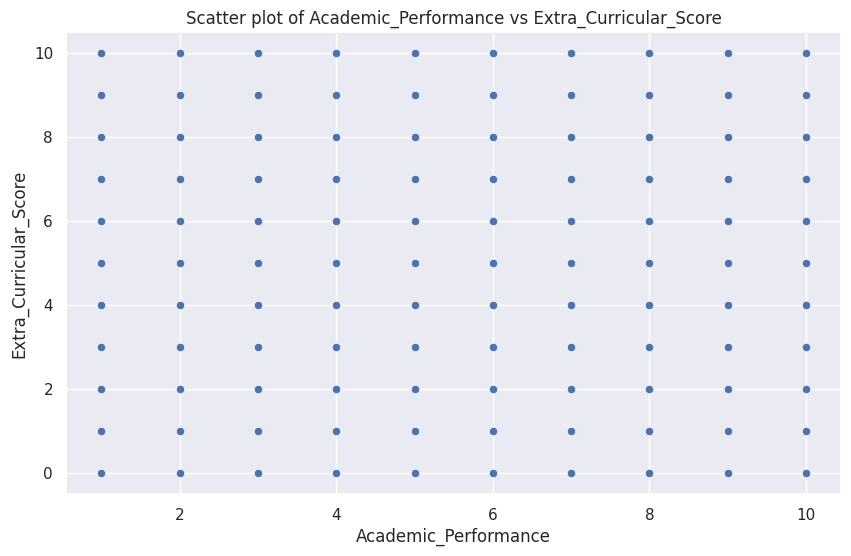

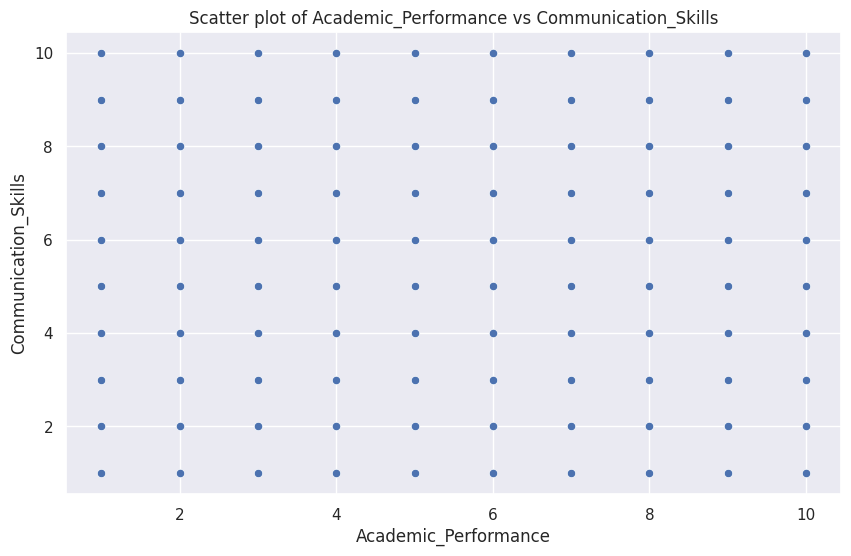

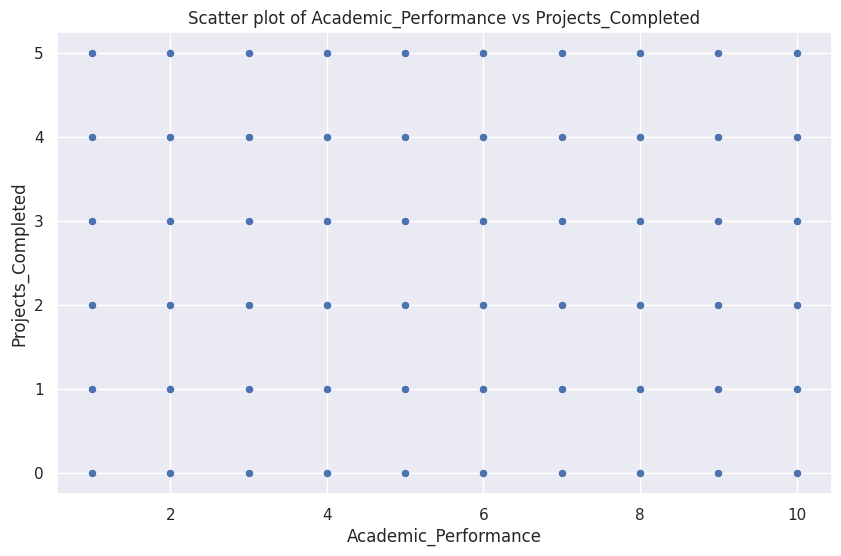

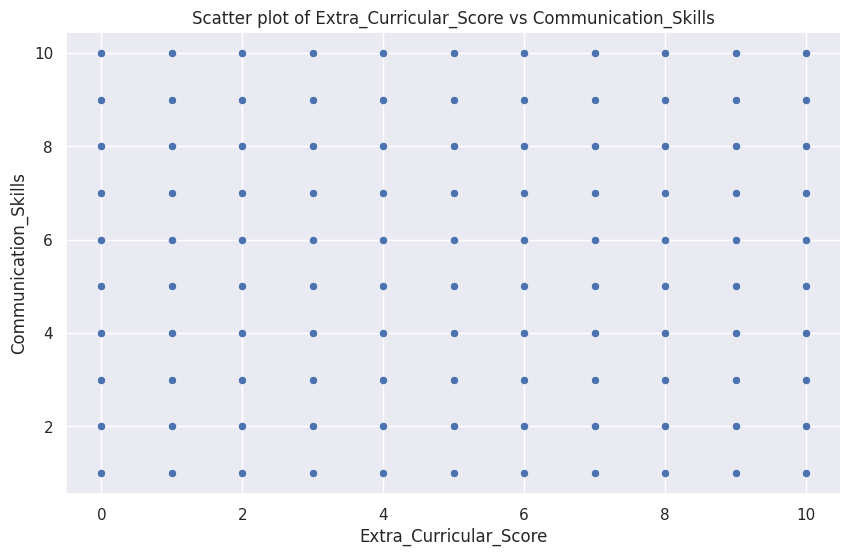

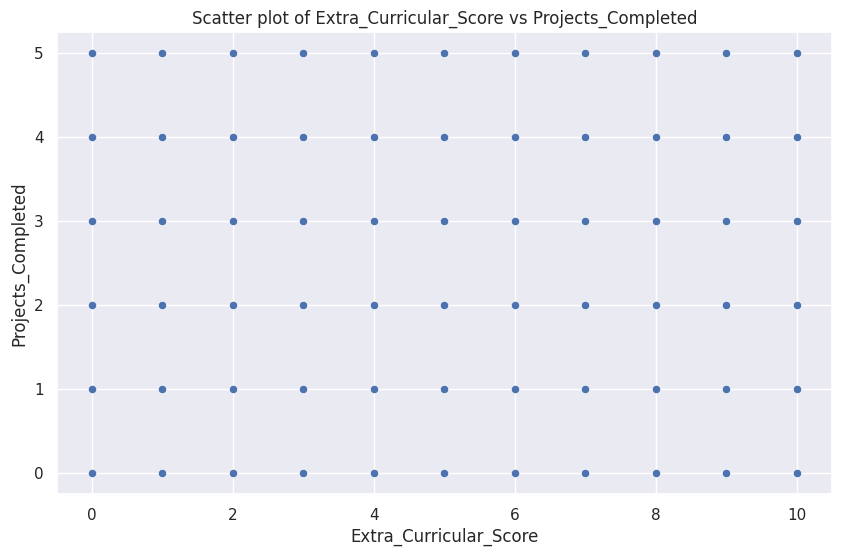

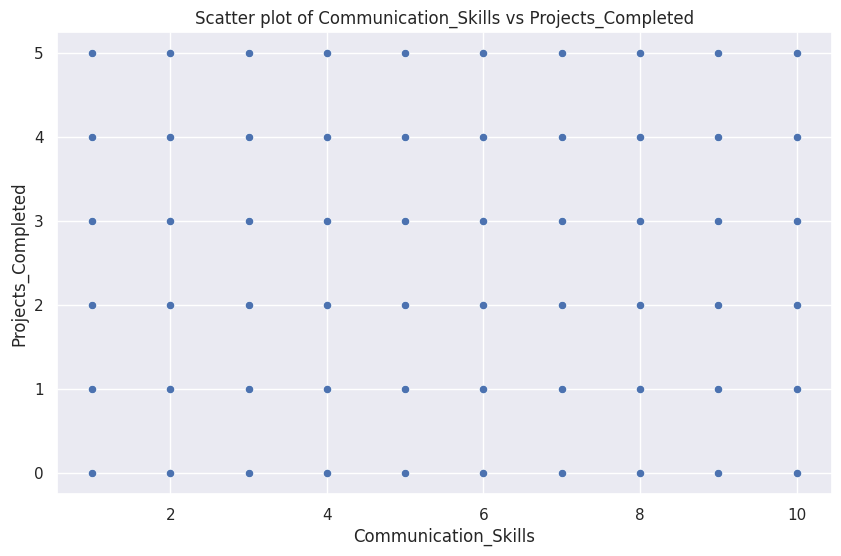

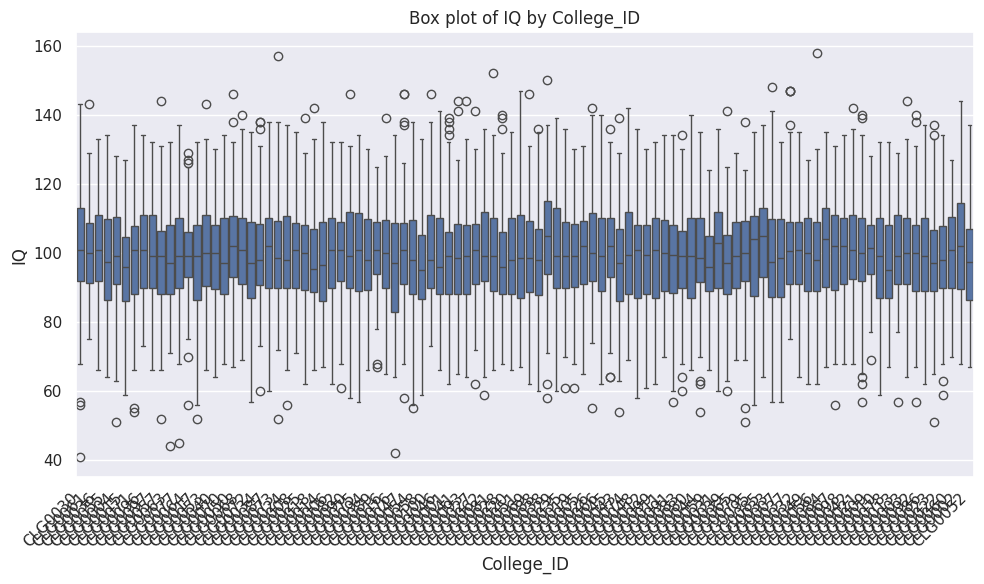

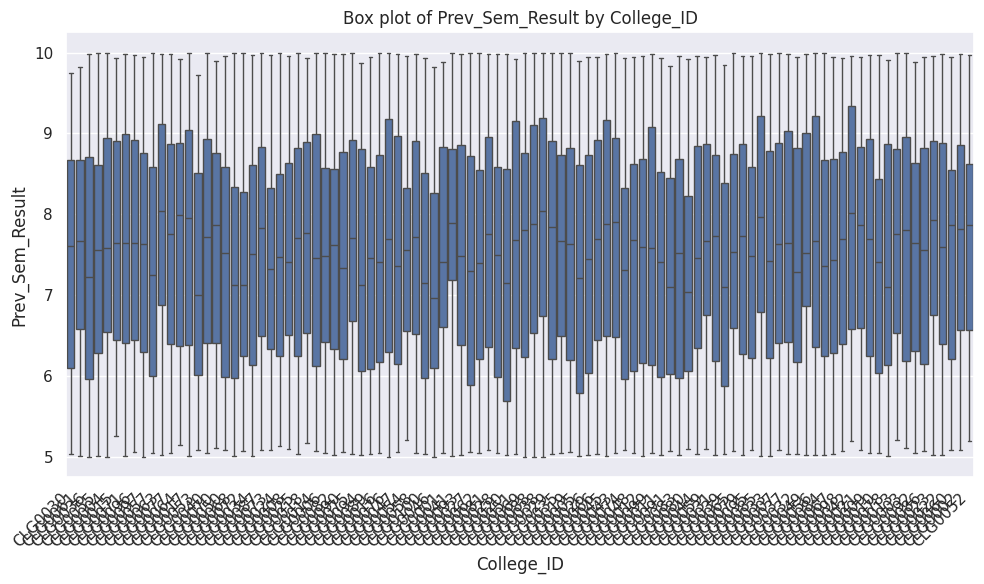

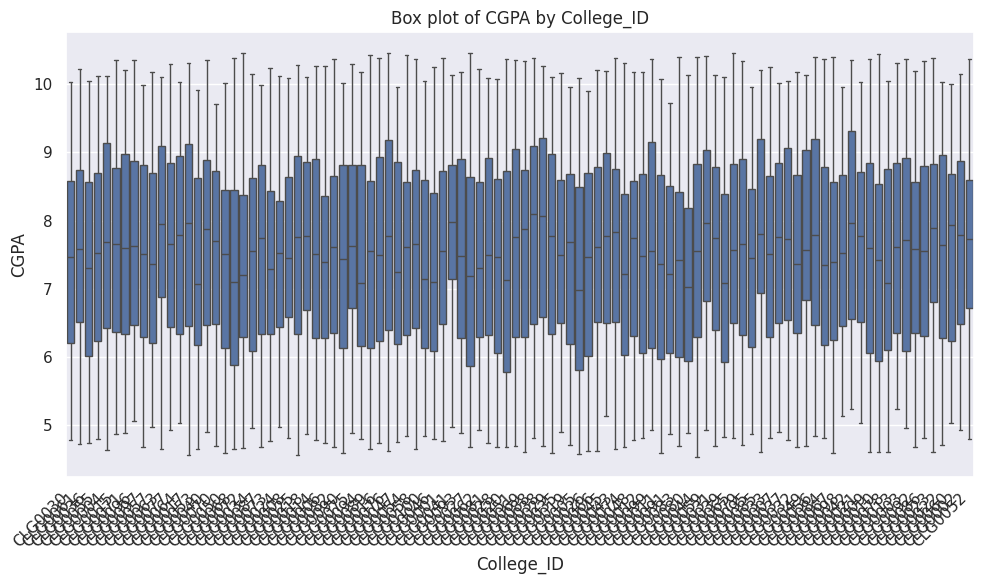

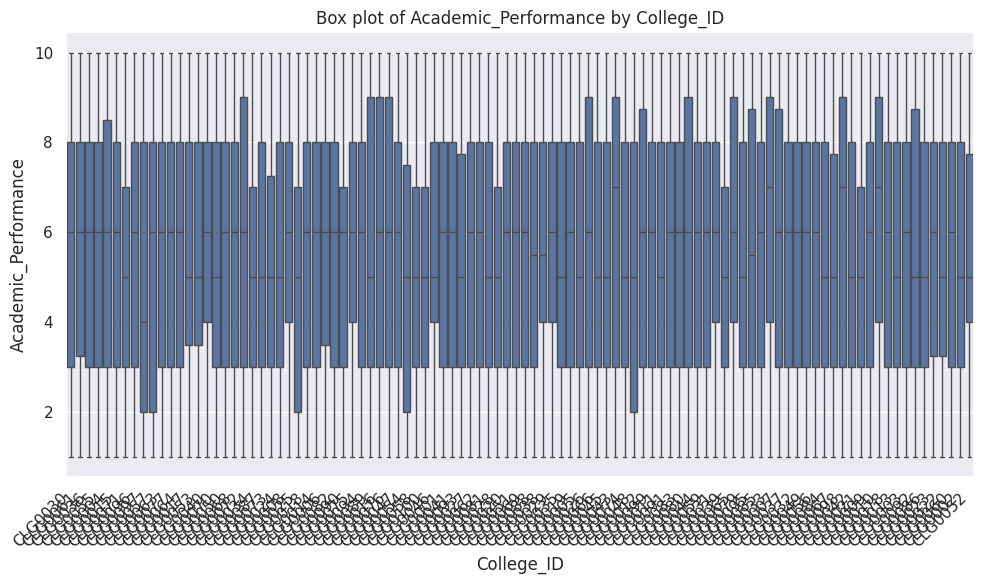

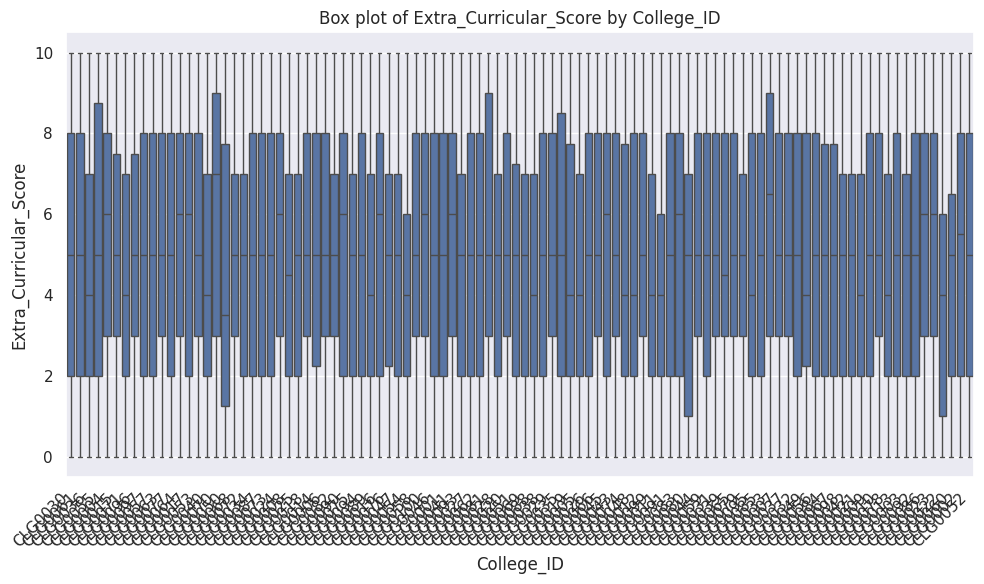

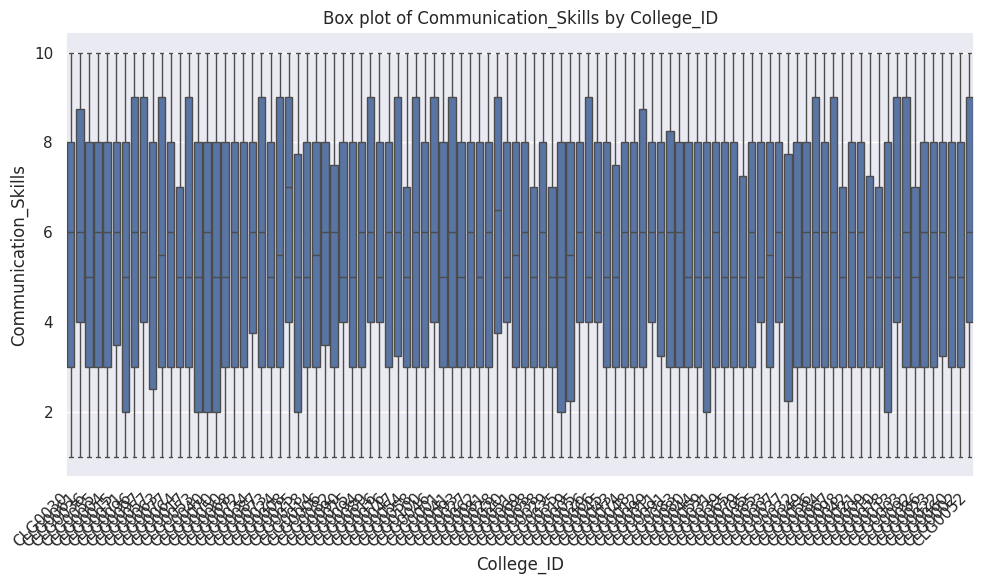

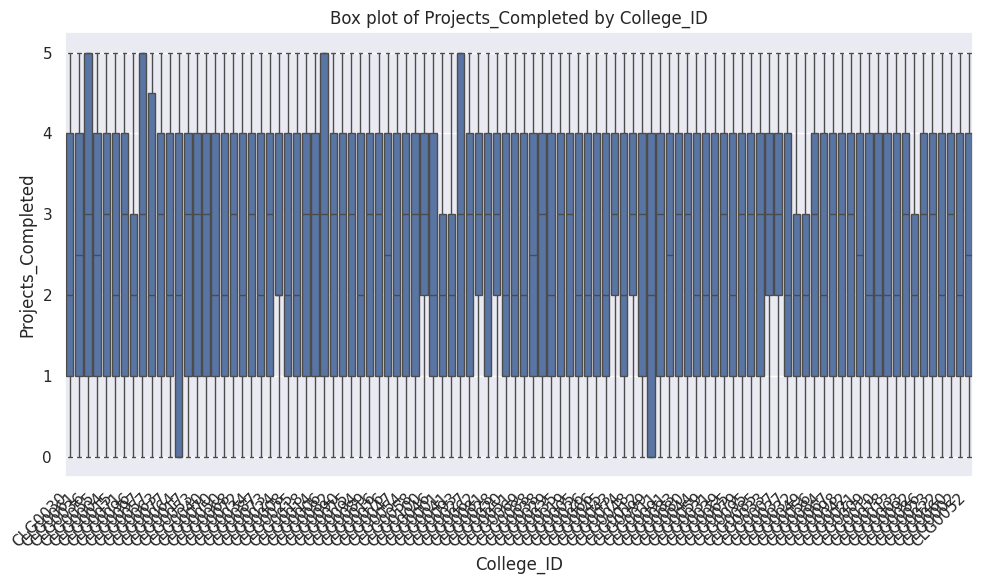

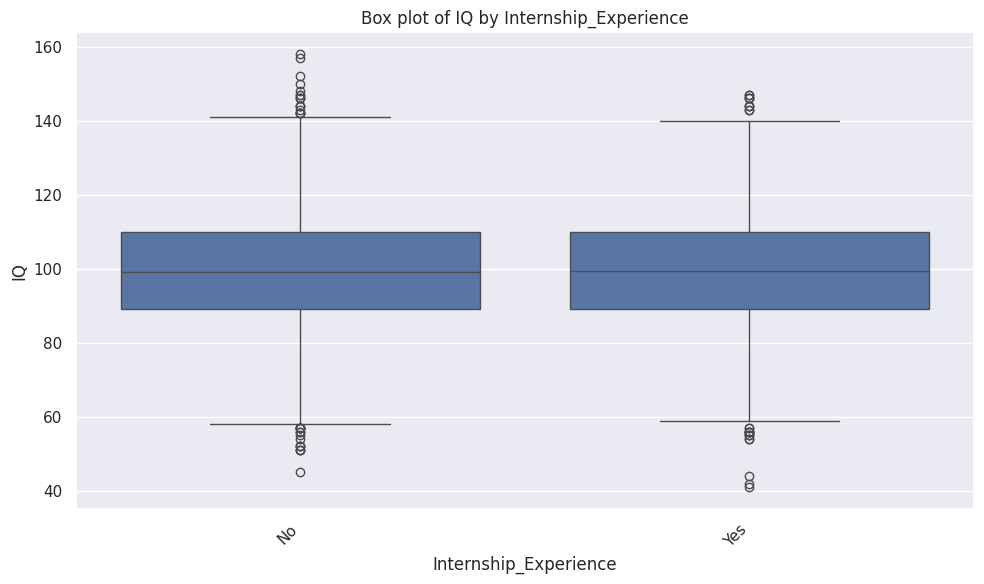

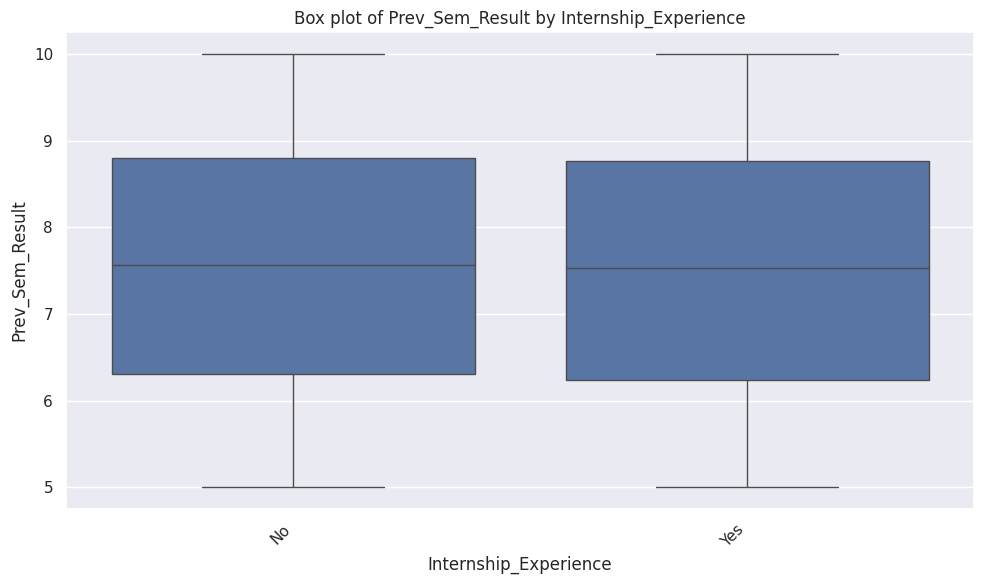

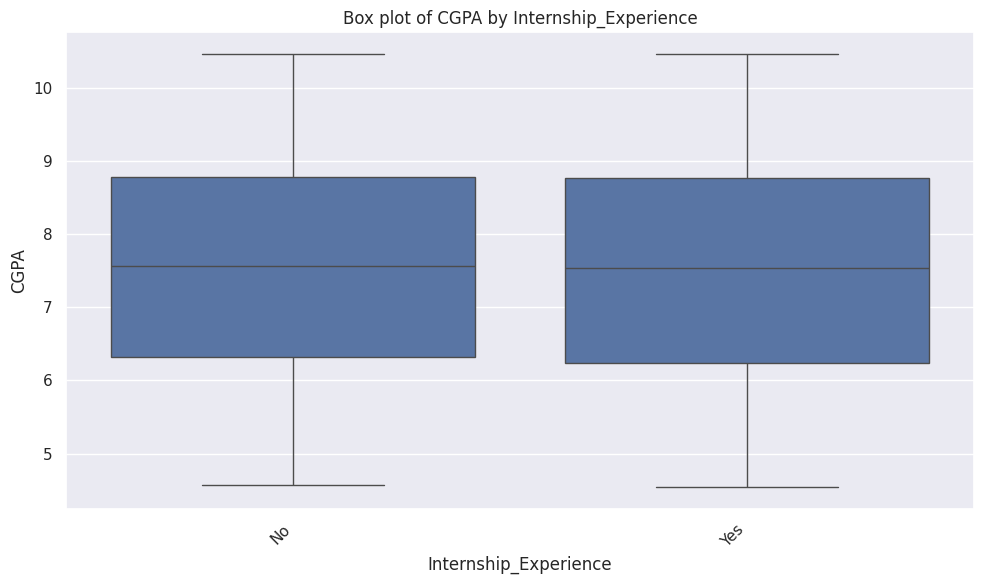

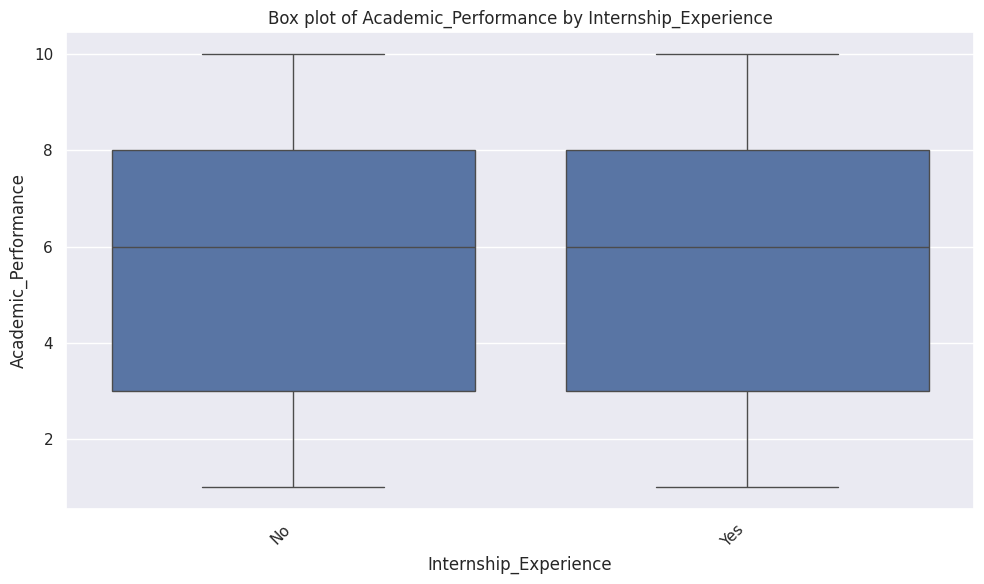

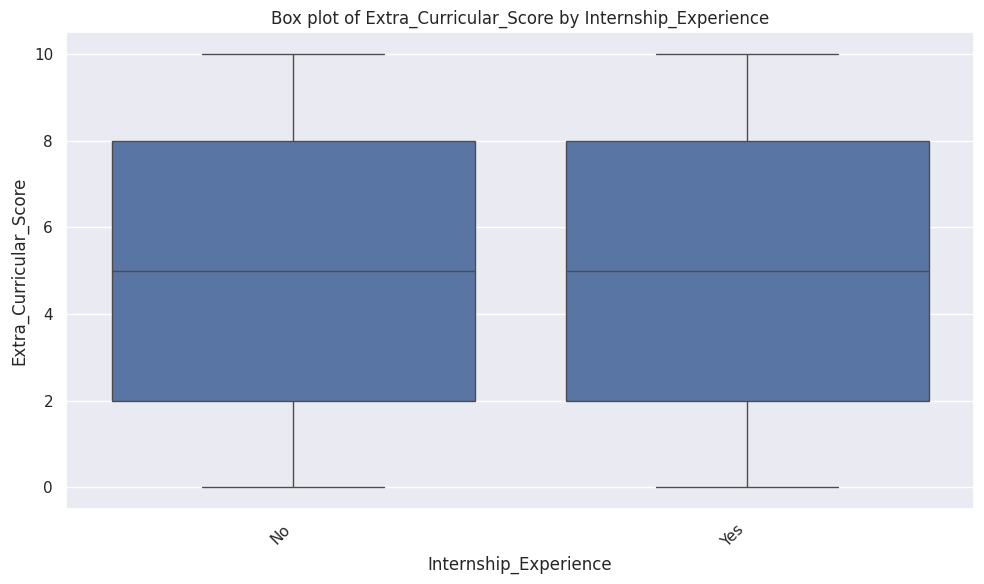

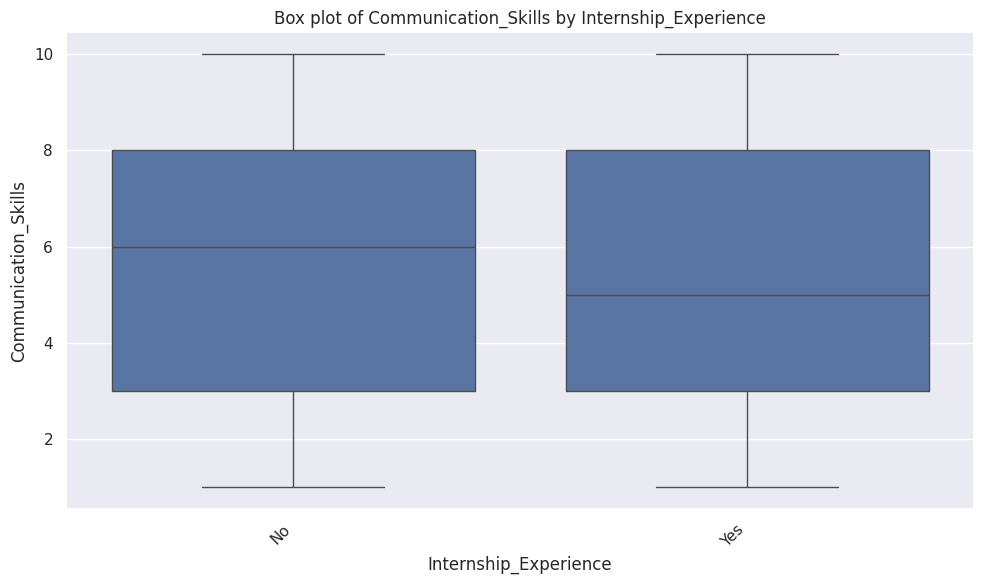

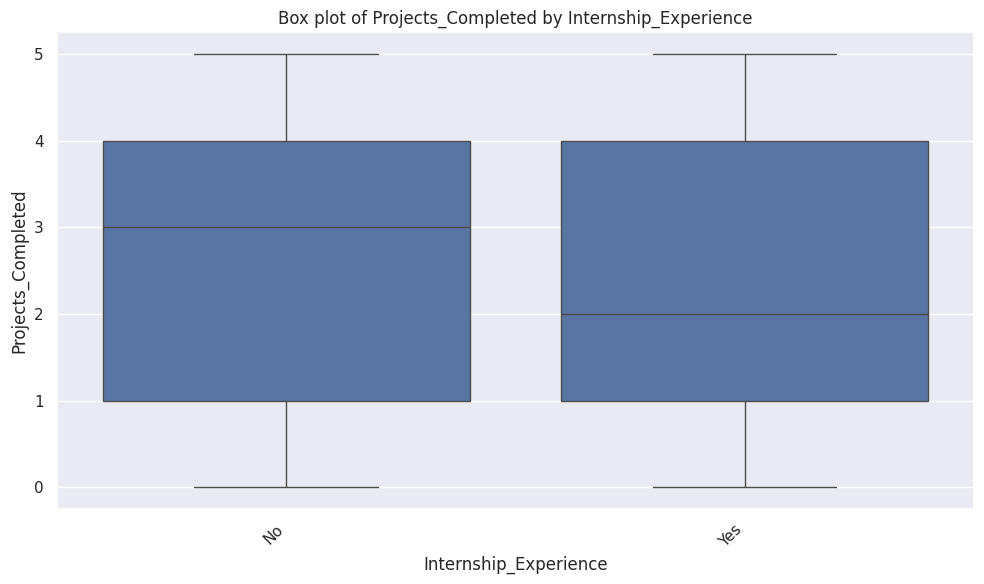

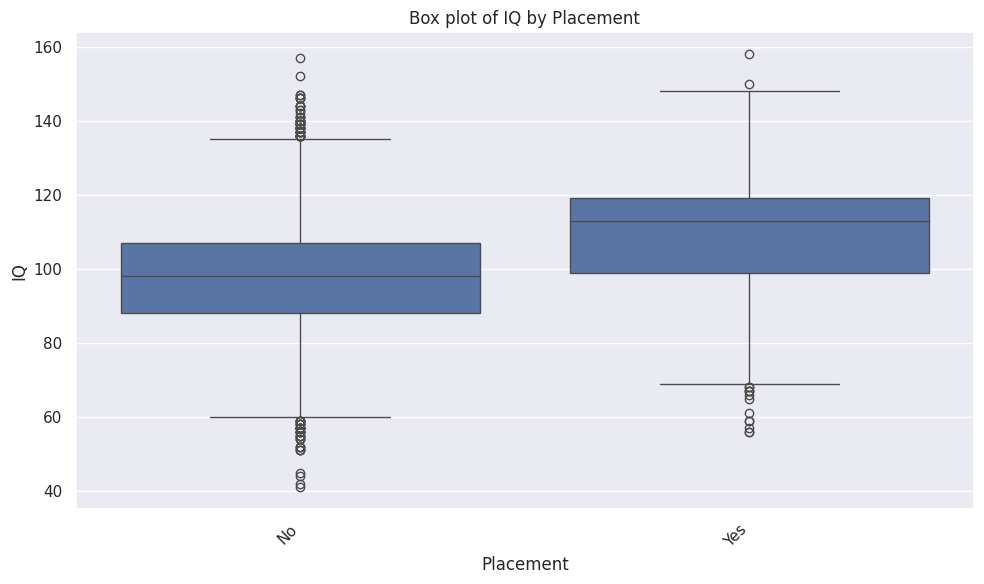

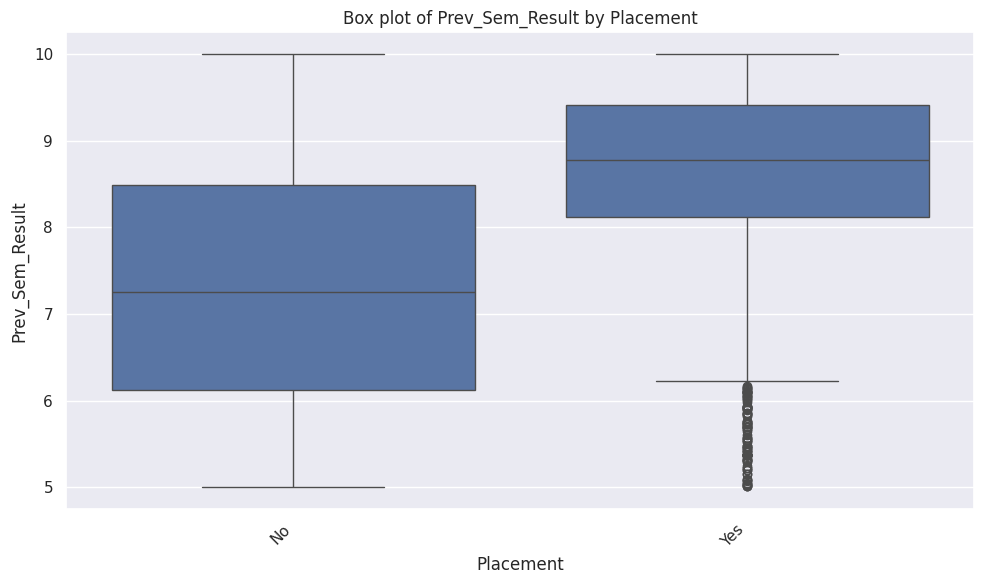

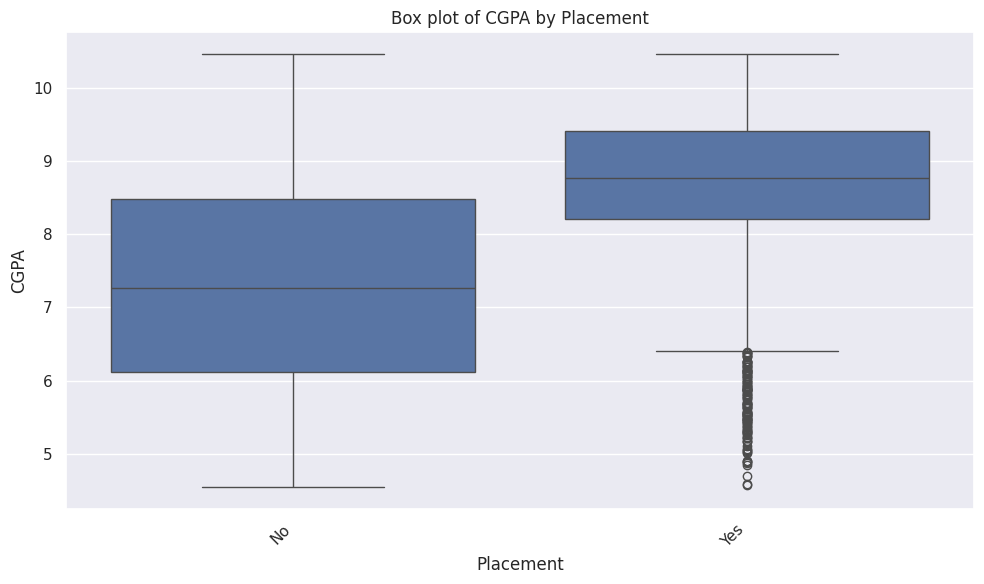

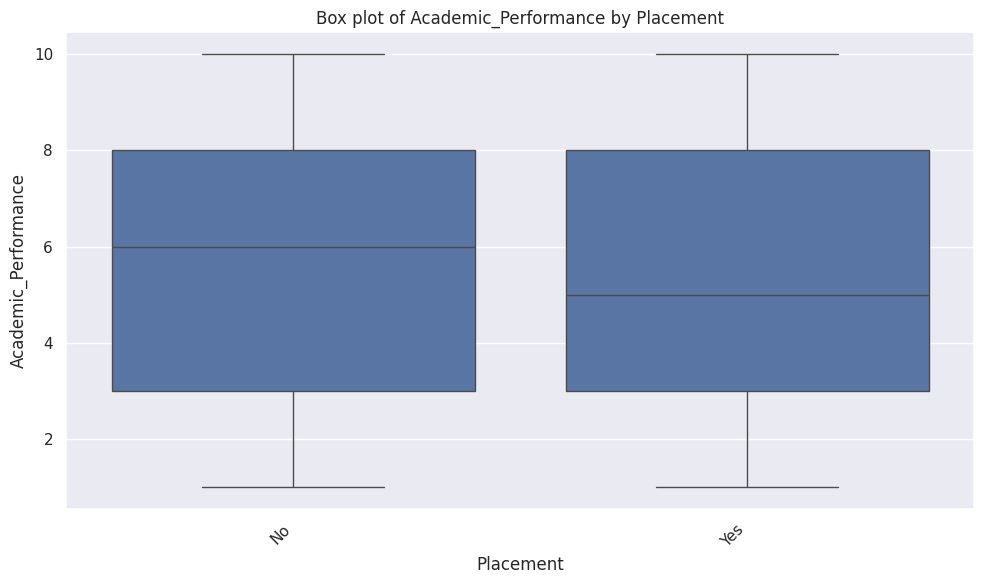

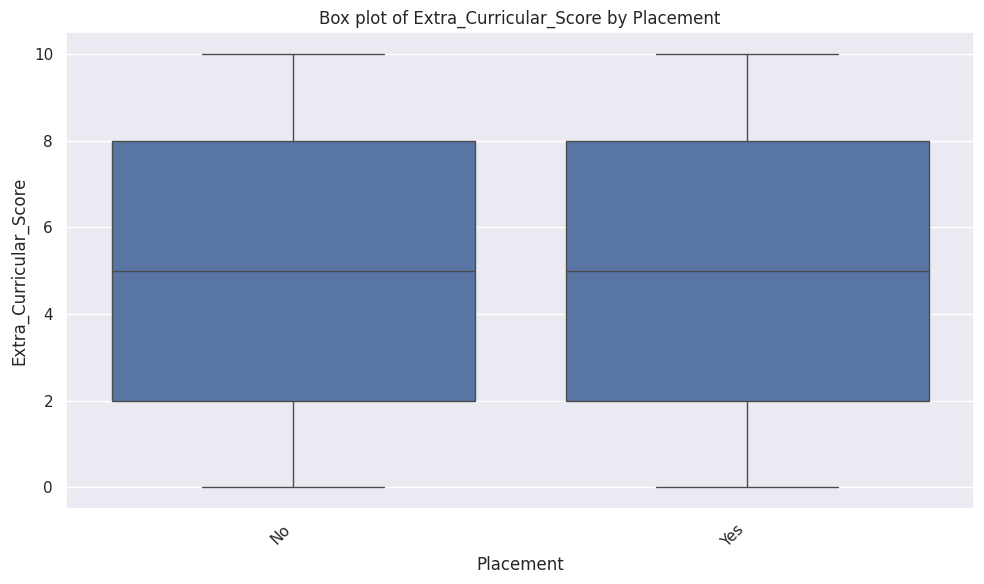

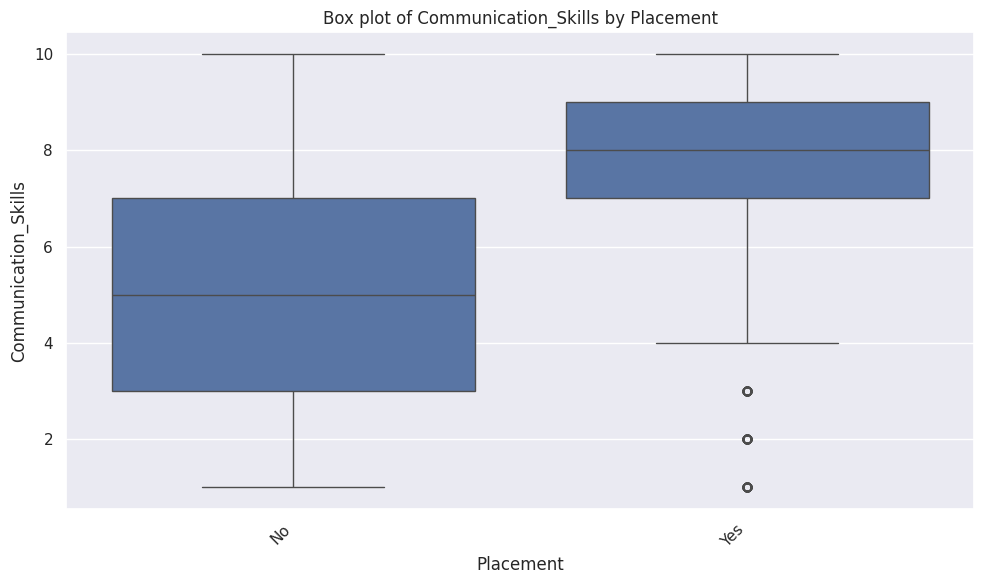

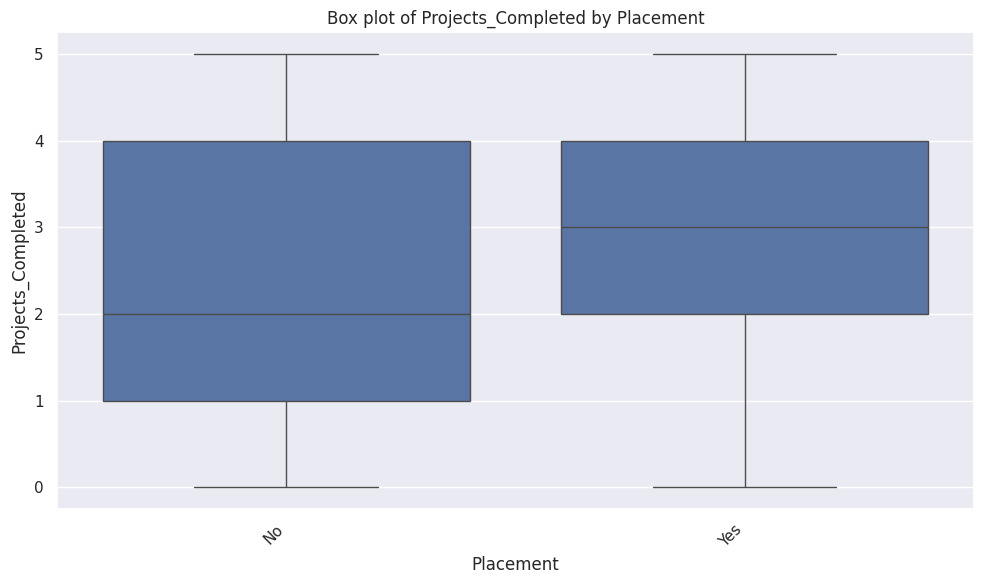

In [16]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

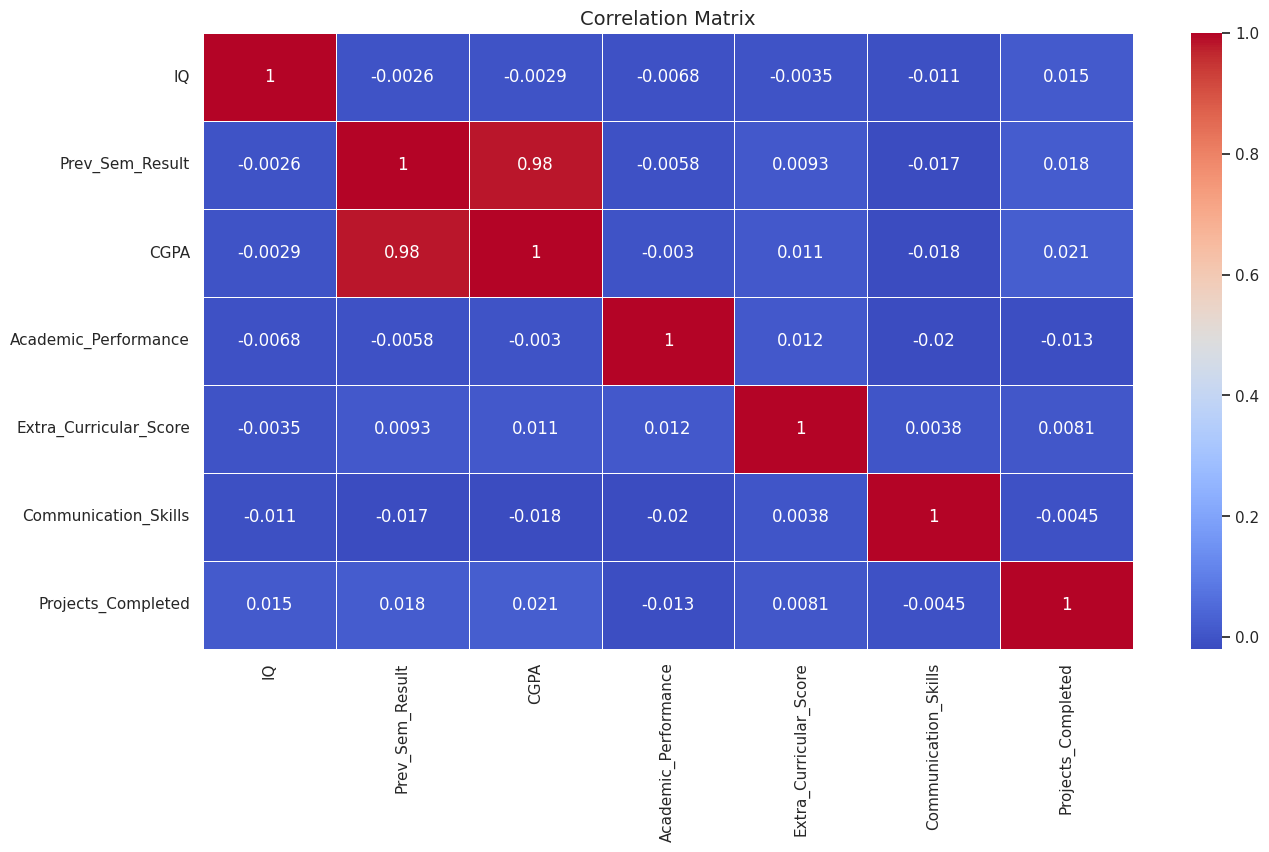

In [17]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank you